In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
import folium
from folium.plugins import Draw
from IPython.display import display, HTML, IFrame
from scipy import optimize
import ast

In [2]:
from IPython.core.display import display, HTML

display(HTML("""
<style>
.jp-OutputArea-output {
    overflow-y: auto;
}
</style>
"""))


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\3993278352.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
# Load the dataset
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Sample data from Vesna vLandedWells.xlsx'  
df = pd.read_excel(file_path)

In [4]:
# Read the first Excel sheet (cumulative data)
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Cumulative Prod for sample data.xlsx'
cumulative_df = pd.read_excel(file_path)

In [5]:
df = pd.merge(df, cumulative_df, on='UWI10', how='left')

In [6]:
# Identify rows in df that do not have a match in cumulative_df
no_match_df = df[df['Cumulative oil mbo'].isnull() & 
                        df['Cumulative gas mmcf'].isnull() & 
                        df['Cumulative water mbbl'].isnull()]
# Print the UWI10 values that did not have a match
if no_match_df.empty:
    print("All UWI10 values in the detailed well data have corresponding matches in the cumulative data.")
else:
    print("UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:")
    print(no_match_df['UWI10'].tolist())

    # Print the rows with no matching cumulative data
    print("\nRows with no matching cumulative data:")
    print(no_match_df)

UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:
[4231739846, 4231745088, 4231742586, 4231743077, 4231742706, 4231742957, 4231744274, 4231741133, 4231744299, 4231741625, 4231742348, 4231743929, 4231741974, 4222738740, 4231743680, 4231743123, 4231740964, 4231744025, 4231742393, 4231743949, 4231742628, 4231741518, 4231740773, 4231744700, 4231744406, 4231741742, 4231739610, 4231744242, 4231739461, 4231744280, 4231739891, 4231740757, 4222741501, 4231740770, 4231742769, 4231743757, 4231741072, 4231743858, 4231740168, 4231742731, 4231739863, 4231743107, 4231742998, 4231743100, 4231741508, 4231743917, 4231740738, 4231744053, 4222740293, 4231742382, 4231741245, 4231741599]

Rows with no matching cumulative data:
         UWI10             UWI                             WellName  \
0   4231739846  42317398460000                   SALE RANCH 20E #5H   
1   4231745088  42317450880000       AMOCO-BLANCHE 2-28 UNIT 1 #115   
2   4231742586  423

In [7]:
def robust_parse(x):
    if pd.isna(x):
        return [None] * 7  # Handle NaNs by returning a list of Nones
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)  # Attempt to parse string as a Python literal
        else:
            return [x] + [None] * 6  # If x is not a string, return it as the first element with None padding
    except Exception as e:
        #print(f"Failed to parse: {x} with error {e}")  # Optionally log the error for debugging
        return [None] * 7  # Return None values if parsing fails

In [8]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P20', 'Gas_Params_P20', 'Oil_Params_P35', 'Gas_Params_P35', 
    'Oil_Params_P50', 'Gas_Params_P50', 'Oil_Params_P65', 'Gas_Params_P65', 
    'Oil_Params_P80', 'Gas_Params_P80', 'Water_Params_P50'
]
# Apply robust parsing to each column
for col in param_columns:
    df[col] = df[col].apply(robust_parse)
# Split each parameter into its own column
new_columns = []
for col in param_columns:
    expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                     f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                     f'{col}_LimDeclineRate']
    temp_df = pd.DataFrame(df[col].tolist(), columns=expanded_cols)
    # Convert numeric columns to float
    for num_col in expanded_cols:
        if num_col.endswith('_Method'):
            temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
        else:
            temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
    df = pd.concat([df, temp_df], axis=1)

# Drop the original parameter columns
df.drop(columns=param_columns, inplace=True)

In [9]:
# Handling NaN values differently for categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df.columns:
    if column in categorical_columns:
        df[column] = df[column].fillna('Unknown')  # Using 'Unknown' for categorical data
    else:
        df[column] = df[column].fillna(0)  # Assuming 0 is a reasonable fill for numerical data
# Drop rows where any of the new parameter columns have missing data
df.dropna(subset=[col for col in df.columns if 'Params' in col], inplace=True)

In [10]:
# Drop rows where 'FluidPerFoot_bblft' or 'ProppantPerFoot' are zero
df = df[(df['FluidPerFoot_bblft'] != 0) & (df['ProppantPerFoot'] != 0)]
df = df[(df['EUR_30yr_Actual_Gas_P50_MMCF'] != 0) & (df['EUR_30yr_Actual_Oil_P50_MBO'] != 0) & (df['EUR_30yr_Actual_Water_P50_MBBL'] != 0)]
df = df[(df['HEELPOINT_LAT'] != 0)]

In [11]:
# Define a function to replace zeros with the P50 value for the same category
def replace_zeros_with_P50(df):
    # Replace for EUR values
    phases = ['Oil', 'Gas', 'Water']  # Assuming Water is also needed; adjust as necessary
    years = ['30yr']  # Adjust or extend if there are other year ranges
    
    for phase in phases:
        for year in years:
            p50_col = f'EUR_{year}_Actual_{phase}_P50_' + ('MBO' if phase != 'Gas' else 'MMCF')
            if phase == 'Water':
                p50_col = f'EUR_{year}_Actual_{phase}_P50_MBBL'  # Assuming water is measured in MBBL

            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'EUR_{year}_Actual_{phase}_{p}_' + ('MBO' if phase != 'Gas' else 'MMCF')
                if phase == 'Water':
                    p_col = f'EUR_{year}_Actual_{phase}_{p}_MBBL'
                
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

    # Replace for parameters
    params = ['Method', 'BuildupRate', 'MonthsInProd', 'InitialProd', 'DiCoefficient', 'BCoefficient', 'LimDeclineRate']
    ###Log
    for phase in ['Oil', 'Gas', 'Water']:  # Assuming Water parameters are also needed
        for param in params:
            p50_col = f'{phase}_Params_P50_{param}'
            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'{phase}_Params_{p}_{param}'
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

In [12]:
replace_zeros_with_P50(df)

In [13]:
# Drop rows where latitude or longitude values are missing
df.dropna(subset=['HEELPOINT_LAT', 'HEELPOINT_LON', 'MIDPOINT_LAT', 'MIDPOINT_LON', 'TOEPOINT_LAT', 'TOEPOINT_LON'], inplace=True)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['HEELPOINT_LON'], df['HEELPOINT_LAT']))

# Create a LineString for each well
gdf['line'] = gdf.apply(lambda row: LineString([
    (row['HEELPOINT_LON'], row['HEELPOINT_LAT']),
    (row['MIDPOINT_LON'], row['MIDPOINT_LAT']),
    (row['TOEPOINT_LON'], row['TOEPOINT_LAT'])
]), axis=1)

# Create a GeoDataFrame with the LineStrings
line_gdf = gpd.GeoDataFrame(gdf, geometry='line')

# Calculate bounds to set the map's initial view
bounds = line_gdf.total_bounds  # [minx, miny, maxx, maxy]
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]  # [(miny + maxy)/2, (minx + maxx)/2]

# Create a folium map centered on the calculated center
m = folium.Map(location=center, zoom_start=10)

# Fit map to bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])


# Add the lines to the map
for _, row in line_gdf.iterrows():
    line_points = [
        (row['HEELPOINT_LAT'], row['HEELPOINT_LON']),
        (row['MIDPOINT_LAT'], row['MIDPOINT_LON']),
        (row['TOEPOINT_LAT'], row['TOEPOINT_LON'])
    ]
    folium.PolyLine(line_points, color='blue').add_to(m)
    # Add marker for midpoint with a popup showing coordinates or other info
    folium.Marker(location=line_points[1], popup=f'Well ID: {row["WellName"]}', tooltip='Click for info').add_to(m)

# Add draw control to the map to allow for area selection
draw = Draw(export=True)
m.add_child(draw)

# Display the map in the Jupyter notebook
m.save('wells_map.html')
display(IFrame('wells_map.html', width=700, height=500))


In [14]:
def add_neighbor_eur_cumulative(df):
    if df is None:
        raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

    # Check if the UWI column exists
    if 'UWI' not in df.columns:
        raise ValueError("The input DataFrame does not contain the 'UWI' column.")

    # Define the EUR columns we're interested in
    eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
                       'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
                       'EUR_30yr_Actual_Oil_P80_MBO']
    eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
                       'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
                       'EUR_30yr_Actual_Gas_P80_MMCF']
    cumulative_columns = ['Cumulative oil mbo', 'Cumulative gas mmcf', 'Cumulative water mbbl']

    # Check if the required EUR columns exist
    missing_columns = [col for col in eur_oil_columns + eur_gas_columns + cumulative_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

    # Create a mapping DataFrame that will be used for mapping EUR values
    eur_cumulative_map = df.set_index('UWI')[eur_oil_columns + eur_gas_columns + cumulative_columns].fillna(0).copy()

    # Create a dictionary to hold the new columns
    new_columns = {}

    # Iterate over NNAZ and NNSZ columns
    for prefix in ['NNAZ', 'NNSZ']:
        num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
        for i in range(1, num_cols + 1):
            uwi_col = f'{prefix}_{i}_UWI'
            if uwi_col in df.columns:  # Ensure the UWI column exists
                for eur_col in eur_oil_columns + eur_gas_columns + cumulative_columns:
                    new_col_name = f'{prefix}_{i}_{eur_col}'
                    # Use the map function to add EUR values from the eur_cumulative_map DataFrame
                    new_columns[new_col_name] = df[uwi_col].map(eur_cumulative_map[eur_col])

    # Concatenate the new columns to the original dataframe
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

    return df

In [15]:
### ADD NEIGBOURING STIMULATION INFORMATION

In [16]:
df = add_neighbor_eur_cumulative(df)

In [17]:
columns_to_drop=['UWI10', 'CompletionDate' ,'UWI', 'WellName','NNAZ_1_UWI','NNAZ_2_UWI','NNAZ_3_UWI','NNAZ_4_UWI','NNAZ_5_UWI','NNAZ_6_UWI','NNSZ_1_UWI',
 'NNSZ_2_UWI','LeaseName', 'WellNumber', 'CurrentOperatorName', 'OriginalOperatorName', 'DrillingContractorName', 'PermitDate', 'SpudDate','FORMATION_CONDENSE', 'Unique_PDP_ID','EUR_30yr_Actual_Oil_P20_MBO',
 'EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Oil_P35_MBO', 'EUR_30yr_Actual_Gas_P35_MMCF', 'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Gas_P50_MMCF',
 'EUR_30yr_Actual_Oil_P65_MBO', 'EUR_30yr_Actual_Gas_P65_MMCF', 'EUR_30yr_Actual_Oil_P80_MBO', 'EUR_30yr_Actual_Gas_P80_MMCF', 'EUR_30yr_Actual_Water_P50_MBBL','WELL_TORTUOSITY','DEPTH_TO_TOP_2Q',
 'DEPTH_TO_TOP_3Q', 'DEPTH_TO_TOP_4Q', 'AZIMUTH','DEPTH_ABOVE_ZONE_2Q',  'DEPTH_ABOVE_ZONE_3Q', 'DEPTH_ABOVE_ZONE_4Q','Cumulative oil mbo', 
 'Cumulative gas mmcf', 'Cumulative water mbbl','AVERAGE_INCLINATION','DEPTH_TO_TOP_1Q','HEELPOINT_DEPTH','TOEPOINT_DEPTH',
 'NNAZ_3_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_3_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_3_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_3_Cumulative oil mbo', 'NNAZ_3_Cumulative gas mmcf', 'NNAZ_3_Cumulative water mbbl',
 'NNAZ_4_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_4_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_4_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_4_Cumulative oil mbo', 'NNAZ_4_Cumulative gas mmcf',
 'NNAZ_4_Cumulative water mbbl', 'NNAZ_5_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P35_MBO',
 'NNAZ_5_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P80_MBO',
 'NNAZ_5_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNAZ_5_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_5_Cumulative oil mbo',
 'NNAZ_5_Cumulative gas mmcf', 'NNAZ_5_Cumulative water mbbl', 'NNAZ_6_EUR_30yr_Actual_Oil_P20_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P65_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_6_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNAZ_6_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P80_MMCF',
 'NNAZ_6_Cumulative oil mbo', 'NNAZ_6_Cumulative gas mmcf', 'NNAZ_6_Cumulative water mbbl','NNAZ_3_FORMATION', 'NNAZ_4_FORMATION',
 'NNAZ_5_FORMATION', 'NNAZ_6_FORMATION'
]
# Dropping the columns
df.drop(columns=columns_to_drop, inplace=True)
#months_in_prod_columns = [col for col in df.columns if '_MonthsInProd' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_Method' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
#months_in_prod_columns = [col for col in df.columns if 'LimDeclineRate' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)

In [18]:
# non_null_counts = df.count()

# # Display columns with discrepancies in their count of non-null values
# # This assumes the DataFrame has rows where some columns may be consistently non-null
# max_count = non_null_counts.max()
# discrepancy_columns = non_null_counts[non_null_counts < max_count]
# discrepancy_columns

In [19]:
list(df)

['PRIMARY_FORMATION',
 'Typecurve',
 'BasinTC',
 'HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'WELL_TRAJECTORY',
 'PRIMARY_FORMATION_1Q',
 'PRIMARY_FORMATION_2Q',
 'PRIMARY_FORMATION_3Q',
 'PRIMARY_FORMATION_4Q',
 'NNAZ_1_FORMATION',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_FORMATION',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_FORMATION',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_FORMATION',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'COMPLETION_RELATIONSHIP',
 'HEELPOINT_LAT',
 'HEELPOINT_LON',
 'MIDPOINT_LAT',
 'MIDPOINT_LON',
 'MIDPOINT_DEPTH',
 'TOEPOINT_LAT',
 'TOEPOINT_LON',
 'PRIMARY_FORMATION_BELOW',
 'AVERAGE_DEPTH_T

In [20]:
# Fill missing values with zero
df = df.fillna(0)

In [21]:
non_null_counts = df.count()

# Display columns with discrepancies in their count of non-null values
# This assumes the DataFrame has rows where some columns may be consistently non-null
max_count = non_null_counts.max()
discrepancy_columns = non_null_counts[non_null_counts < max_count]
discrepancy_columns

Series([], dtype: int64)

In [22]:
# Define bounds for each basin in a dictionary.
# The keys are basin names, and the values are tuples of (lat_min, lat_max, lon_min, lon_max).
basin_bounds = {
    'Midland': {'lat_range': (29, 34), 'lon_range': (-110, -109)}
    # Add more basins with their geographic bounds 
}
def assign_basin_tc(row):
    # Check if BasinTC is 0 or missing (use pd.isna() and explicitly handle pd.NA)
    if pd.isna(row['BasinTC'])== 'Unknown' or row['BasinTC'] == 0:
        matched_basin = None
        for basin, bounds in basin_bounds.items():
            # Ensure all comparisons are done within bounds
            if ((bounds['lat_range'][0] <= row['HEELPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['HEELPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['MIDPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['MIDPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['TOEPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['TOEPOINT_LON'] <= bounds['lon_range'][1])):
                matched_basin = basin
                break
        return matched_basin if matched_basin else row['BasinTC']
    return row['BasinTC']

In [23]:
# Apply the function to each row
df['BasinTC'] = df.apply(assign_basin_tc, axis=1)
# Drop rows where 'BasinTC' is 'Unknown'
df = df[df['BasinTC'] != 'Unknown']

months_in_prod_columns = [col for col in df.columns if '_LAT' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_LON' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'COMPLETION_RELATIONSHIP' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'WELL_TRAJECTORY' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'PRIMARY_FORMATION' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'Typecurve' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df_orig = df

# Print the shape of the DataFrame to confirm rows have been dropped
print(f"Updated DataFrame shape: {df.shape}")

Updated DataFrame shape: (1015, 158)


In [24]:
list(df)

['BasinTC',
 'HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'NNAZ_1_FORMATION',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_FORMATION',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_FORMATION',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_FORMATION',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'MIDPOINT_DEPTH',
 'AVERAGE_DEPTH_TO_NEXT_ZONE',
 'DEPTH_ABOVE_ZONE_1Q',
 'TotalDepthTVD',
 'FORMATION_CONDENSED',
 'FluidPerFoot_bblft',
 'ProppantPerFoot',
 'Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',


In [25]:
# Ensure BasinTC and FORMATION_CONDENSED are categorical
df['BasinTC'] = df['BasinTC'].astype(str)
df['FORMATION_CONDENSED'] = df['FORMATION_CONDENSED'].astype(str)

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV


In [27]:
# Define categorical and numerical columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
categorical_columns = [col for col in df.select_dtypes(include=['object', 'category']).columns.tolist() if col not in ['BasinTC', 'FORMATION_CONDENSED']]
# Prepare data for modeling
y_headers = [col for col in df.columns if 'Params' in col]             # Define target headers dynamically if needed
numerical_columns = [col for col in df.columns if col not in categorical_columns + ['BasinTC', 'FORMATION_CONDENSED', *y_headers]]
# Update feature_columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
feature_columns = numerical_columns + categorical_columns

In [28]:
list(y_headers)

['Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',
 'Gas_Params_P20_BuildupRate',
 'Gas_Params_P20_MonthsInProd',
 'Gas_Params_P20_InitialProd',
 'Gas_Params_P20_DiCoefficient',
 'Gas_Params_P20_BCoefficient',
 'Gas_Params_P20_LimDeclineRate',
 'Oil_Params_P35_BuildupRate',
 'Oil_Params_P35_MonthsInProd',
 'Oil_Params_P35_InitialProd',
 'Oil_Params_P35_DiCoefficient',
 'Oil_Params_P35_BCoefficient',
 'Oil_Params_P35_LimDeclineRate',
 'Gas_Params_P35_BuildupRate',
 'Gas_Params_P35_MonthsInProd',
 'Gas_Params_P35_InitialProd',
 'Gas_Params_P35_DiCoefficient',
 'Gas_Params_P35_BCoefficient',
 'Gas_Params_P35_LimDeclineRate',
 'Oil_Params_P50_BuildupRate',
 'Oil_Params_P50_MonthsInProd',
 'Oil_Params_P50_InitialProd',
 'Oil_Params_P50_DiCoefficient',
 'Oil_Params_P50_BCoefficient',
 'Oil_Params_P50_LimDeclineRate',
 'Gas_Params_P50_BuildupRate',
 'Ga

In [29]:
# # Calculate the number of unique categories and their names for each column
# category_info = {col: {'count': df[col].nunique(), 'names': df[col].unique()} for col in categorical_columns}
# # Print the number of categories grouped by the header name
# for header, info in category_info.items():
#     print(f"{header}:")
#     print(f"  Count of Categories: {info['count']}")
#     print(f"  Categories: {info['names']}\n")
# # Print the shape of the DataFrame to confirm rows have been dropped
# print(f"Updated DataFrame shape: {df.shape}")

In [30]:
# Initialize a dictionary to keep LabelEncoders for each column
encoders = {}
# Encode categorical columns and store the encoders
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert and encode
    encoders[col] = le  # Store the encoder for inverse_transform

In [31]:
# Define function to prepare data
def remove_outliers(df, columns, threshold=3):
    for col in columns:
        df = df[(np.abs(stats.zscore(df[col])) < threshold)]
    return df

In [32]:
#df=remove_outliers(df, numerical_columns)

In [33]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=30)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=30)

In [34]:
def prepare_data(df, numerical_columns, categorical_columns):
    df = df.copy()  # Create a copy of the dataframe to avoid SettingWithCopyWarning
    df.loc[:, categorical_columns] = df[categorical_columns].astype(np.int32)
    return df
# Define function to filter data by basin and formation
def filter_by_basin_and_formation(dfinput, basin, formation):
    return dfinput[(dfinput['BasinTC'] == basin) & (dfinput['FORMATION_CONDENSED'] == formation)]
def debug_shapes(train, val, test, y_headers):
    print(f'Train X shape: {train.shape}, Train Y shape: {train[y_headers].shape}')
    print(f'Val X shape: {val.shape}, Val Y shape: {val[y_headers].shape}')
    print(f'Test X shape: {test.shape}, Test Y shape: {test[y_headers].shape}')
# Define a function to find optimal n_components for PCA
def optimal_pca_components(data, variance_threshold=0.95):
    pca = PCA().fit(data)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    return optimal_components

In [35]:
# Apply scaling on train, validate, and test sets
input_scaler = RobustScaler()
output_scaler = RobustScaler()

# Apply log transformation to BuildupRate and InitialProd columns before scaling
log_transform_columns = [col for col in y_headers if 'BuildupRate' in col or 'InitialProd' in col]
train_df[log_transform_columns] = train_df[log_transform_columns].apply(lambda x: np.log1p(x.clip(lower=0)))
val_df[log_transform_columns] = val_df[log_transform_columns].apply(lambda x: np.log1p(x.clip(lower=0)))
test_df[log_transform_columns] = test_df[log_transform_columns].apply(lambda x: np.log1p(x.clip(lower=0)))

# Scale numerical columns
input_scaler.fit(train_df[numerical_columns])
train_numerical_scaled = input_scaler.transform(train_df[numerical_columns])
val_numerical_scaled = input_scaler.transform(val_df[numerical_columns])
test_numerical_scaled = input_scaler.transform(test_df[numerical_columns])

# Fit the output scaler
output_scaler.fit(train_df[y_headers])

# # Find optimal PCA components
# optimal_components = optimal_pca_components(train_numerical_scaled, variance_threshold=0.95)
# print(f"Optimal number of PCA components to retain 95% variance: {optimal_components}")

# # Apply PCA to reduce dimensionality
# pca = PCA(n_components=optimal_components)  # Use dynamically determined components
# pca.fit(train_numerical_scaled)  # Fit PCA only on the training data
# train_numerical_pca = pca.transform(train_numerical_scaled)
# val_numerical_pca = pca.transform(val_numerical_scaled)
# test_numerical_pca = pca.transform(test_numerical_scaled)



RobustScaler()

In [36]:
# # Create new PCA columns names
# pca_columns = [f"PCA_{i}" for i in range(train_numerical_pca.shape[1])]

# # Replace original numerical data with PCA transformed data
# train_df[pca_columns] = train_numerical_pca
# val_df[pca_columns] = val_numerical_pca
# test_df[pca_columns] = test_numerical_pca

In [37]:
list(train_df)

['BasinTC',
 'HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'NNAZ_1_FORMATION',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_FORMATION',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_FORMATION',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_FORMATION',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'MIDPOINT_DEPTH',
 'AVERAGE_DEPTH_TO_NEXT_ZONE',
 'DEPTH_ABOVE_ZONE_1Q',
 'TotalDepthTVD',
 'FORMATION_CONDENSED',
 'FluidPerFoot_bblft',
 'ProppantPerFoot',
 'Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',


In [38]:
list(train_df)

['BasinTC',
 'HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'NNAZ_1_FORMATION',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_FORMATION',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_FORMATION',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_FORMATION',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'MIDPOINT_DEPTH',
 'AVERAGE_DEPTH_TO_NEXT_ZONE',
 'DEPTH_ABOVE_ZONE_1Q',
 'TotalDepthTVD',
 'FORMATION_CONDENSED',
 'FluidPerFoot_bblft',
 'ProppantPerFoot',
 'Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',


In [39]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()

In [40]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Embedding, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from sklearn.utils.validation import check_is_fitted

In [41]:
# Real-time plotting callback class
class RealTimePlottingCallback(Callback):
    def __init__(self, combo_description):
        super().__init__()
        self.combo_description = combo_description
        self.epochs = []
        self.losses = []
        self.val_losses = []
    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
    def on_train_end(self, logs=None):
        plt.figure(figsize=(10, 4))
        plt.plot(self.epochs, self.losses, label='Training Loss', color='blue')
        plt.plot(self.epochs, self.val_losses, label='Validation Loss', color='red')
        plt.title(f'Training and Validation Loss for {self.combo_description}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [42]:
def build_model(pca_components, categorical_columns, df, output_size, embedding_output_dim=20, dense_layer_sizes=[128, 64], dropout_rate=0.3, regularization=None, activation='relu', optimizer='adam', loss_function='mse'):
    numerical_input = Input(shape=(pca_components,), name='num_input')
    categorical_inputs = [Input(shape=(1,), name=f'cat_input_{i}') for i, _ in enumerate(categorical_columns)]
    embeddings = [Embedding(input_dim=df[col].nunique() + 1, output_dim=embedding_output_dim, name=f'emb_{col}')(cat_input)
                  for cat_input, col in zip(categorical_inputs, categorical_columns)]
    flat_embeddings = [Flatten()(emb) for emb in embeddings]
    merged = Concatenate()([numerical_input] + flat_embeddings)
    x = merged
    for size in dense_layer_sizes:
        x = Dense(size, activation=activation, kernel_regularizer=regularization)(x)
        x = Dropout(dropout_rate)(x)
    output = Dense(output_size, activation='linear')(x)
    model = Model(inputs=[numerical_input] + categorical_inputs, outputs=output)
    if optimizer == 'adam':
        opt = Adam(learning_rate=0.001)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=0.001)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=0.001)
    model.compile(optimizer=opt, loss=loss_function)
    return model


Optimal PCA components for BasinTC: Midland, FORMATION_CONDENSED: WCA: 14
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000246521E7AA0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\440731754.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_train[pca_columns] = combo_train_pca
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\440731754.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_train[pca_columns] = combo_train_pca
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\440731754.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

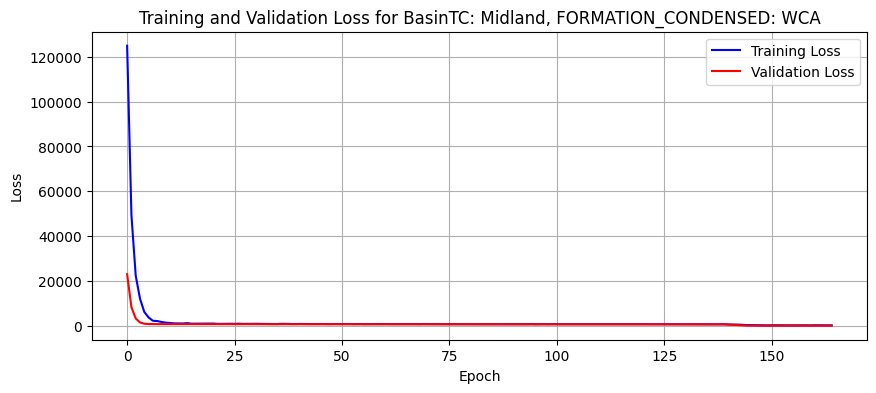

Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000246521E7AA0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L1 object at 0x000002465E1BA240>, 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'}


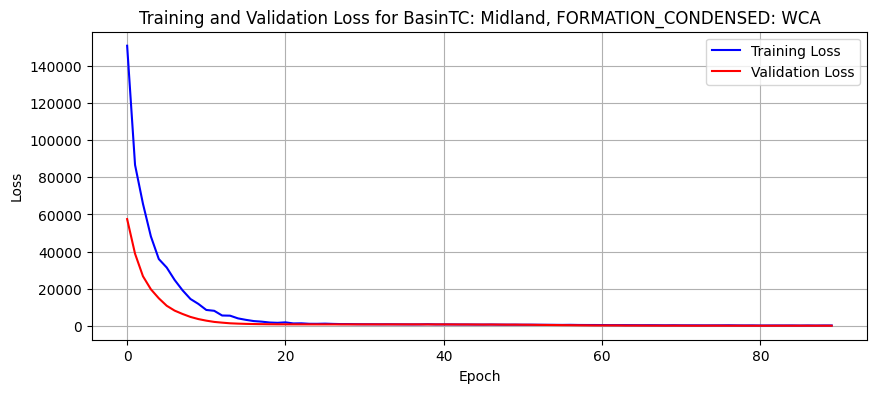

Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L1 object at 0x000002465E1BA240>, 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'}


In [43]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
# unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()
configurations = [
    {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'},
   # {'embedding_output_dim': 30, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.4, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'sgd', 'loss_function': 'mae'},
    {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': l1(0.01), 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'}
]
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
specific_combinations = df[
    (df['BasinTC'] == 'Midland') & 
    #(df['FORMATION_CONDENSED'].isin(['LSS', 'WCA', 'WCB', 'WCD']))
    (df['FORMATION_CONDENSED'].isin(['WCA']))
].drop_duplicates(subset=['BasinTC', 'FORMATION_CONDENSED'])
models = {}
pca_models = {}  # To store PCA models

for index, row in specific_combinations.iterrows():
    basin = row['BasinTC']
    formation = row['FORMATION_CONDENSED']
    combo_description = f'BasinTC: {basin}, FORMATION_CONDENSED: {formation}'    
    combo_train = filter_by_basin_and_formation(train_df, basin, formation)
    combo_val = filter_by_basin_and_formation(val_df, basin, formation)
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    
    # Determine optimal PCA components for the specific combination
    optimal_components = optimal_pca_components(combo_train[numerical_columns])
    print(f"Optimal PCA components for {combo_description}: {optimal_components}")
    
    # Apply PCA
    pca = PCA(n_components=optimal_components)
    pca.fit(combo_train[numerical_columns])
    pca_models[(basin, formation)] = pca  # Store the PCA model for this combination
    combo_train_pca = pca.transform(combo_train[numerical_columns])
    combo_val_pca = pca.transform(combo_val[numerical_columns])
    combo_test_pca = pca.transform(combo_test[numerical_columns])

    pca_columns = [f"PCA_{i}" for i in range(combo_train_pca.shape[1])]
    combo_train[pca_columns] = combo_train_pca
    combo_val[pca_columns] = combo_val_pca
    combo_test[pca_columns] = combo_test_pca

    combo_train = combo_train.drop(columns=numerical_columns)
    combo_val = combo_val.drop(columns=numerical_columns)
    combo_test = combo_test.drop(columns=numerical_columns)
    
    output_size = len(train_df[y_headers].columns)
    
    for config in configurations:
        print(f"Starting training for combination: {combo_description} with config: {config}")
        
        # Build model with the current configuration
        model = build_model(optimal_components, categorical_columns, df, output_size, **config)
        
        real_time_plotter = RealTimePlottingCallback(combo_description=combo_description)
        model.fit(
            x=[combo_train[pca_columns].values] + [combo_train[col].astype(int).values.reshape(-1, 1) for col in categorical_columns], 
            y=combo_train[y_headers].values,  # Use entire y_headers as output
            validation_data=(
                [combo_val[pca_columns].values] + [combo_val[col].astype(int).values.reshape(-1, 1) for col in categorical_columns],
                combo_val[y_headers].values  # Use entire y_headers as output
            ),
            epochs=1000, 
            batch_size=50, 
            callbacks=[
                real_time_plotter, 
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), 
                ReduceLROnPlateau(monitor='val_loss', factor=0.001, patience=10)
            ],
            verbose=0
        )      
        models[(basin, formation, str(config))] = model
        print(f"Training completed for combination: {combo_description} with config: {config}")

In [44]:
# Function to denormalize numerical data with optional PCA inverse transformation
def denormalize_data_input(data, scaler, pca=None):
    if pca is not None:
        data = pca.inverse_transform(data)
    return scaler.inverse_transform(data)

# Function to denormalize data and revert log transformation
def denormalize_data_output(data, scaler, log_transform_columns):
    # Inverse transform the scaled data
    denormalized_data = scaler.inverse_transform(data)
    denormalized_df = pd.DataFrame(denormalized_data, columns=scaler.get_feature_names_out())
    
    # Revert the log transformation (expm1)
    denormalized_df[log_transform_columns] = np.expm1(denormalized_df[log_transform_columns])
    
    return denormalized_df

# Function to decode categorical data
def decode_categorical(data, encoders, column_names):
    decoded_data = {}
    for i, col in enumerate(column_names):
        le = encoders[col]
        decoded_data[col] = le.inverse_transform(data[:, i].astype(int))
    return decoded_data

# Adjusted denormalize and decode function
def denormalize_and_decode(train_df, pca_columns, categorical_columns, y_headers, input_scaler, output_scaler, encoders, pca=None):
    train_df[pca_columns] = denormalize_data_input(train_df[pca_columns], input_scaler, pca)
    log_transform_columns = [col for col in y_headers if 'InitialProd' in col]
    train_df[y_headers] = denormalize_data_output(train_df[y_headers], output_scaler, log_transform_columns)
    decoded_categorical = decode_categorical(train_df[categorical_columns].values, encoders, categorical_columns)
    for col in categorical_columns:
        train_df[col] = decoded_categorical[col]
    return train_df

In [69]:
# Function to generate hyperbolic decline curve
def hyperbolic_decline(t, qi, di, b):
    return qi / ((1 + b * di * t) ** (1/b))

# def modified_hyperbolic(t, qi, Di, b, Dlim, IBU, MBU, buildup_method='Linear'):
#     """
#     Calculates the production rate using a modified hyperbolic decline model with an exponential buildup phase.
    
#     Parameters:
#     t (array-like): Time array (months).
#     qi (float): Initial production rate after the build-up period (bbl/day).
#     Di (float): Initial decline rate.
#     b (float): Hyperbolic exponent.
#     Dlim (float): Limiting decline rate for exponential decline.
#     IBU (float): Initial build-up rate.
#     MBU (int): Months for the build-up period.
#     buildup_method (str): Method for buildup calculation ('Flat', 'Linear', 'Exp').

#     Returns:
#     array-like: Production rate at each time point.
#     """
#     # Ensure MBU is treated as an integer
#     MBU = int(MBU)
    
#     # Initialize the q_model array
#     q_model = np.zeros_like(t)
    
#     # Calculate build-up phase
#     if MBU > 0:
#         # Extract the buildup data
#         buildup_time = t[t < MBU]
        
#         if buildup_method == 'Flat':
#             Rate_0 = qi
#             slope = 0
#             buildup_rate = Rate_0 + slope * buildup_time
#         elif buildup_method == 'Linear':
#             Res_fun = lambda params, x, y: np.array(params[0] + params[1] * x - y)
#             result = optimize.least_squares(Res_fun, x0=[IBU, qi], args=[buildup_time, qi * np.ones_like(buildup_time)])
#             Rate_0 = result.x[0]
#             slope = result.x[1]
#             buildup_rate = Rate_0 + slope * buildup_time
#         elif buildup_method == 'Exp':
#             Res_fun = lambda params, x, y: np.array(params[0] * np.exp(params[1] * x) - y)
#             result = optimize.least_squares(Res_fun, x0=[IBU, qi], args=[buildup_time, qi * np.ones_like(buildup_time)])
#             Rate_0 = result.x[0]
#             slope = result.x[1]
#             buildup_rate = Rate_0 * np.exp(slope * buildup_time)
#         else:
#             raise ValueError("Unknown buildup method. Use 'Flat', 'Linear', or 'Exp'.")
        
#         q_model[t < MBU] = buildup_rate

#     # Guard against zero or negative values for Di and b
#     if Di <= 0 or b <= 0:
#         raise ValueError("Di and b must be positive values.")
    
#     # Cap values to prevent overflow
#     Di = min(Di, 100)
#     b = min(b, 10)
#     Dlim = min(Dlim, 100)

#     # Convert decline rates
#     try:
#         Di = ((1 - 0.01 * Di) ** (-b) - 1) / (12 * b)
#         Dlim = ((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b)
#     except (ZeroDivisionError, OverflowError) as e:
#         print(f"Error in decline rate conversion: {e}")
#         return np.zeros_like(t)
    
#     # Calculate switch point
#     try:
#         qlim = qi * (Dlim / Di) ** (1.0 / b)
#         tlim = ((qi / qlim) ** (b) - 1.0) / (b * Di)
#     except (ZeroDivisionError, OverflowError, ValueError) as e:
#         print(f"Error calculating switch point: {e}")
#         return np.zeros_like(t)
    
#     # Separate hyperbolic and exponential segments
#     t_hyp = t[(t >= MBU) & (t < tlim)]
#     t_exp = t[t >= tlim]
    
#     # Calculate model response
#     try:
#         q_model_hyp = qi * (1.0 + b * Di * (t_hyp - MBU)) ** (-1.0 / b)
#         q_model_exp = qlim * np.exp(-Dlim * (t_exp - tlim))
#     except (ZeroDivisionError, OverflowError, ValueError) as e:
#         print(f"Error calculating model response: {e}")
#         return np.zeros_like(t)
    
#     # Combine all segments
#     q_model[(t >= MBU) & (t < tlim)] = q_model_hyp
#     q_model[t >= tlim] = q_model_exp

#     # Handle potential infinities or large values
#     q_model = np.nan_to_num(q_model, nan=0.0, posinf=np.finfo(float).max, neginf=0.0)
    
#     return q_model
def modified_hyperbolic(time, qi, di, b, Dlim, IBU, MBU, buildup_method='Linear'):
    """
    Calculate the production rate using the Modified Hyperbolic Decline Model with a buildup phase.

    :param time: array-like, time in months
    :param qi: float, initial production rate
    :param di: float, initial decline rate
    :param b: float, hyperbolic coefficient
    :param Dlim: float, limited decline rate
    :param IBU: float, initial buildup rate
    :param MBU: float, months in production for buildup
    :param buildup_method: str, method for buildup ('Flat', 'Linear', 'Exp')
    :return: array-like, production rates
    """

    # Convert decline rates to nominal rates
    di = ((1 - 0.01 * di) ** (-b) - 1) / (12 * b)
    Dlim = ((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b)

    # Calculate switch point
    qlim = qi * (Dlim / di) ** (1.0 / b)
    tlim = ((qi / qlim) ** (b) - 1.0) / (b * di)

    # Initialize the production array
    production = np.zeros_like(time, dtype=float)

    # Calculate production during buildup period
    t_buildup = 1#time[time <= MBU]
    if buildup_method == 'Flat':
        buildup_production = IBU + np.zeros_like(t_buildup)
    elif buildup_method == 'Linear':
        slope = (qi - IBU) / MBU
        buildup_production = IBU + slope * t_buildup
    elif buildup_method == 'Exp':
        slope = np.log(qi / IBU) / MBU
        buildup_production = IBU * np.exp(slope * t_buildup)
    else:
        raise ValueError("Unknown buildup method: {}".format(buildup_method))

    production[:len(t_buildup)] = buildup_production

    # Calculate production during hyperbolic and exponential decline periods
    #t_post_buildup = time[time > MBU]
    t_post_buildup = time[time > 1]
    if len(t_post_buildup) > 0:
        t_hyp = t_post_buildup[t_post_buildup < tlim + MBU]
        t_exp = t_post_buildup[t_post_buildup >= tlim + MBU]

        if len(t_hyp) > 0:
            q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)
            production[len(t_buildup):len(t_buildup) + len(t_hyp)] = q_model_hyp

        if len(t_exp) > 0:
            q_model_exp = qlim * np.exp(-Dlim * (t_exp - (tlim + MBU)))
            production[len(t_buildup) + len(t_hyp):] = q_model_exp

    return production

    
def plot_decline_curves(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    plt.plot(time, actual, 'b-o', label='Actual')
    plt.plot(time, predicted, 'r--x', label='Predicted')
    #plt.yscale('log')
    plt.ylim(1, 100000)
    plt.title(title)
    plt.xlabel('Time (Months)')
    plt.ylabel('Production Rate (bbl/day)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--')
    plt.show()

# Function to generate production rates
def generate_production_rates(y_pred_denormalized, y_true_denormalized, headers, time):
    predicted_productions = []
    actual_productions = []

    for idx in range(len(y_pred_denormalized)):
        qi_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]

        qi_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]

        try:
            predicted_production = modified_hyperbolic(time, qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
            actual_production = modified_hyperbolic(time, qi_true, di_true, b_true, Dlim_true, IBU_true, MBU_true)

            if len(predicted_production) == len(actual_production) == len(time):
                predicted_productions.append(predicted_production)
                actual_productions.append(actual_production)
            else:
                print(f"Skipping index {idx} due to length mismatch: len(pred)={len(predicted_production)}, len(actual)={len(actual_production)}, len(time)={len(time)}")
        except Exception as e:
            print(f"Error in modified_hyperbolic calculation for index {idx}: {e}")
            predicted_production = np.zeros_like(time)
            actual_production = np.zeros_like(time)
            predicted_productions.append(predicted_production)
            actual_productions.append(actual_production)

    return predicted_productions, actual_productions

def calculate_errors(predicted_productions, actual_productions):
    errors = []
    valid_indices = []

    for i, (pred, actual) in enumerate(zip(predicted_productions, actual_productions)):
        if len(pred) == len(actual):
            try:
                mse = mean_squared_error(actual, pred)
                errors.append(mse)
                valid_indices.append(i)
            except ValueError as e:
                print(f"Skipping error calculation for index {i} due to error: {e}")
                errors.append(np.inf)  # Assign a high error for problematic points
        else:
            print(f"Skipping error calculation for index {i} due to length mismatch: len(pred)={len(pred)}, len(actual)={len(actual)}")
            errors.append(np.inf)  # Assign a high error for problematic points

    return errors, valid_indices


def identify_best_worst_matches(errors, y_true_denormalized, y_pred_denormalized):
    best_match_idx = np.argmin(errors)
    worst_match_idx = np.argmax(errors)

    best_match_true = y_true_denormalized.iloc[best_match_idx]
    best_match_pred = y_pred_denormalized.iloc[best_match_idx]

    worst_match_true = y_true_denormalized.iloc[worst_match_idx]
    worst_match_pred = y_pred_denormalized.iloc[worst_match_idx]

    return best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx

def plot_decline_curves(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    plt.plot(time, actual, 'b-o', label='Actual')
    plt.plot(time, predicted, 'r--x', label='Predicted')
    #plt.yscale('log')
    plt.ylim(1, 100000)
    plt.title(title)
    plt.xlabel('Time (Months)')
    plt.ylabel('Production Rate (bbl/day)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--')
    plt.show()

In [70]:
# Define the prediction function
@tf.function(reduce_retracing=True)
def predict_with_model(model, numerical_data, categorical_data):
    return model([numerical_data] + categorical_data)

In [71]:
years = 5
time = np.linspace(1, 12*years, 12*years)  # 5 Years

C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_test.loc[:, col] = combo_test_pca[:, i]
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_test.loc[:, col] = combo_test_pca[:, i]
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

Error in modified_hyperbolic calculation for index 0: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 1: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 2: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 3: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 4: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 5: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 6: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 7: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 8: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 9: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 10: object of type 'int' has no len()
Error in modified_hyperbolic ca

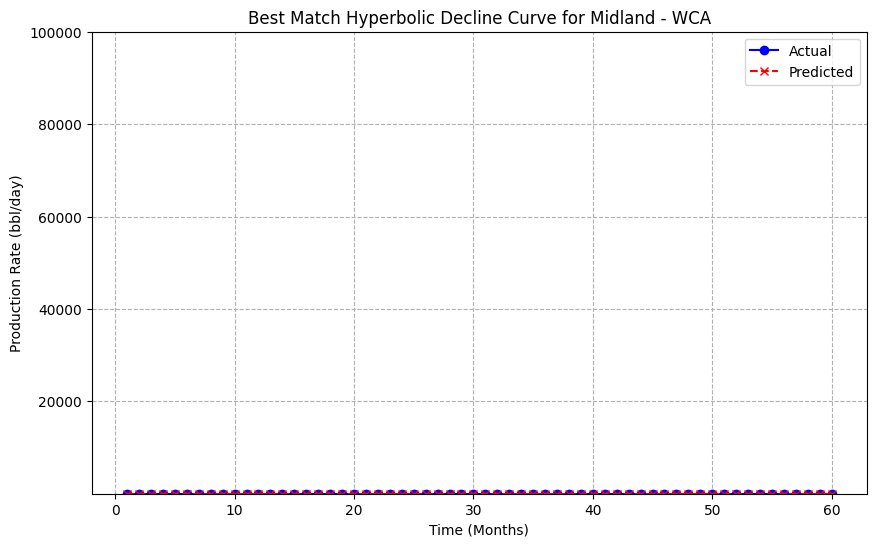

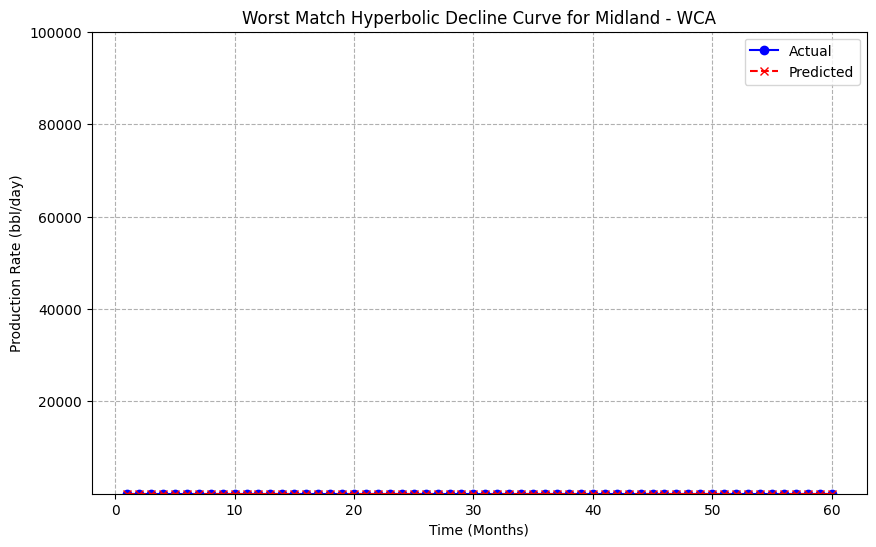

Error calculating metrics for Basin: Midland, Formation: WCA, Config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000246521E7AA0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - Error: Input contains infinity or a value too large for dtype('float32').
Error in modified_hyperbolic calculation for index 0: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 1: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 2: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 3: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 4: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 5: object of type 'int' has no len()
Error in modified_hyperbolic calculation for index 6: object of type 'int' has no len()

C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_test.loc[:, col] = combo_test_pca[:, i]
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combo_test.loc[:, col] = combo_test_pca[:, i]
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_21404\4148649877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

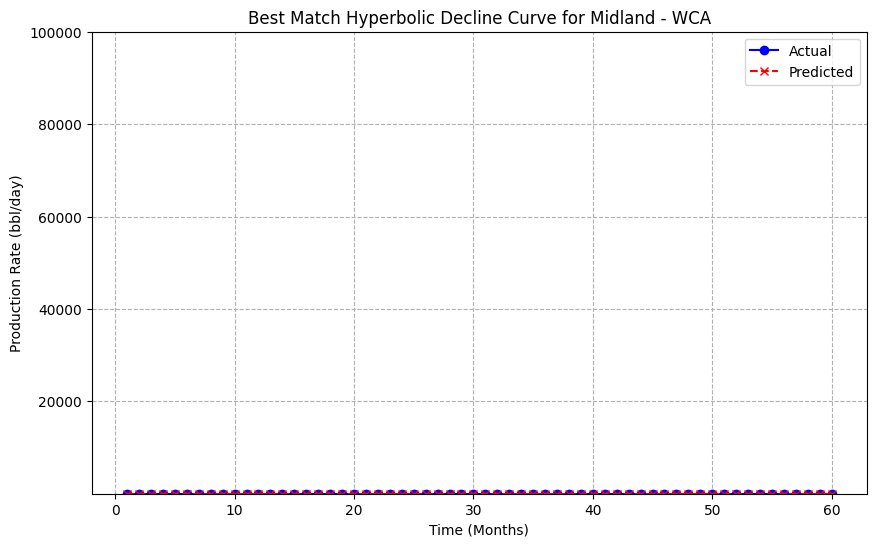

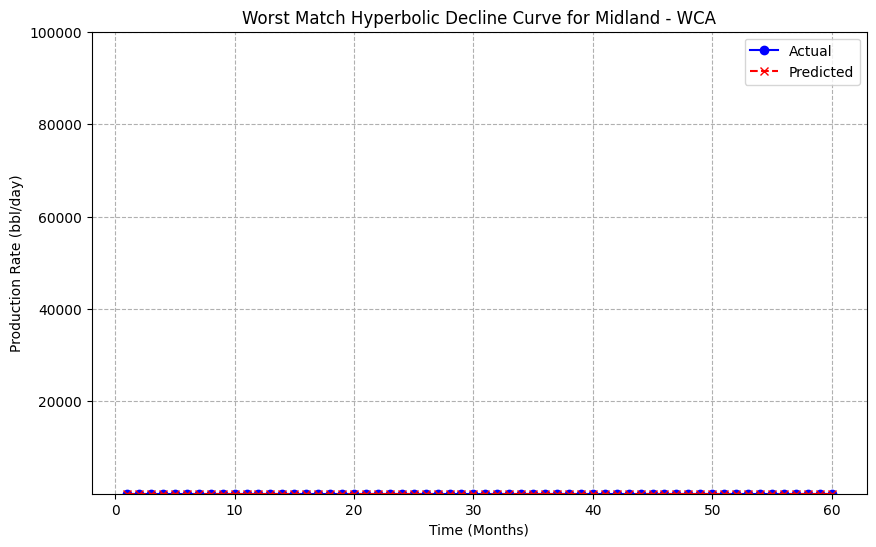

Error calculating metrics for Basin: Midland, Formation: WCA, Config: {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L1 object at 0x000002465E1BA240>, 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'} - Error: Input contains infinity or a value too large for dtype('float32').


In [72]:
evaluation_results = {}
best_performing_models = {}

for (basin, formation, config_str), model in models.items():
    pca = pca_models[(basin, formation)]
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    combo_test_pca = pca.transform(combo_test[numerical_columns])
    for i, col in enumerate(pca_columns):
        combo_test.loc[:, col] = combo_test_pca[:, i]
    combo_test = combo_test.drop(columns=numerical_columns)
    #print(list(combo_test))
    numerical_data = combo_test[pca_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    y_true = combo_test[y_headers].values
    
    y_pred = predict_with_model(model, numerical_data, categorical_data)
    y_pred = y_pred.numpy()

    # Denormalize predictions and actual values
    y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
    y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)
    
    predicted_productions, actual_productions = generate_production_rates(y_pred_denormalized, y_true_denormalized, y_headers, time)
    errors, valid_indices = calculate_errors(predicted_productions, actual_productions)
    
    best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx = identify_best_worst_matches(errors, y_true_denormalized.iloc[valid_indices], y_pred_denormalized.iloc[valid_indices])
    
    # Plot the best match
    best_actual_production = actual_productions[best_match_idx]
    best_predicted_production = predicted_productions[best_match_idx]
    plot_decline_curves(time, best_actual_production, best_predicted_production, f'Best Match Hyperbolic Decline Curve for {basin} - {formation}')
    
    # Plot the worst match
    worst_actual_production = actual_productions[worst_match_idx]
    worst_predicted_production = predicted_productions[worst_match_idx]
    plot_decline_curves(time, worst_actual_production, worst_predicted_production, f'Worst Match Hyperbolic Decline Curve for {basin} - {formation}')
    
    # Calculating evaluation metrics
    try:
        mse = mean_squared_error(y_true_denormalized, y_pred_denormalized)
        mae = mean_absolute_error(y_true_denormalized, y_pred_denormalized)
        evaluation_results[(basin, formation, config_str)] = {'MSE': mse, 'MAE': mae}
        print(f"Performance for Basin: {basin}, Formation: {formation}, Config: {config_str} - MSE: {mse:.4f}, MAE: {mae:.4f}")
        
        # Update best performing model
        if (basin, formation) not in best_performing_models or mse < best_performing_models[(basin, formation)]['MSE']:
            best_performing_models[(basin, formation)] = {'MSE': mse, 'MAE': mae, 'config_str': config_str, 'model': model}
    except ValueError as e:
        print(f"Error calculating metrics for Basin: {basin}, Formation: {formation}, Config: {config_str} - Error: {e}")

# Print the best performing model for each basin and formation
for (basin, formation), best_model_info in best_performing_models.items():
    print(f"Best Performing Model for Basin: {basin}, Formation: {formation} - Config: {best_model_info['config_str']} - MSE: {best_model_info['MSE']:.4f}, MAE: {best_model_info['MAE']:.4f}")